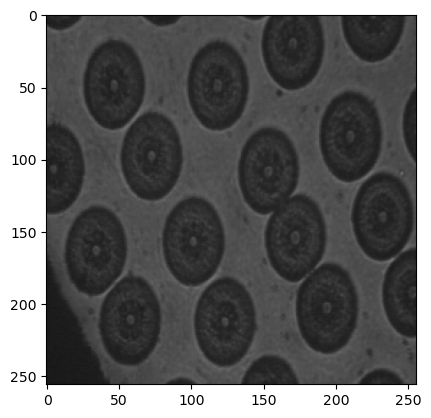

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

sic = cv2.imread('SIC.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(sic, cmap='gray', vmin=0, vmax=255)
plt.show()



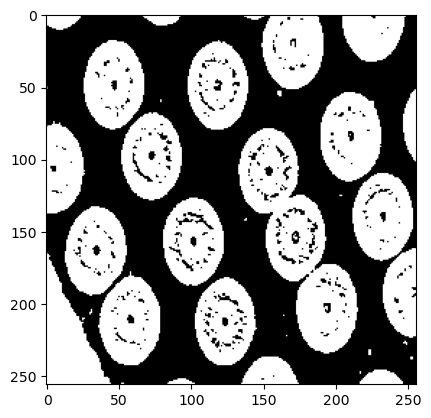

In [2]:
import cv2

thres_value, thres_image = cv2.threshold(sic, 55, 70, cv2.THRESH_BINARY)
thresh_inv = cv2.bitwise_not(thres_image)



plt.imshow(thresh_inv, cmap='gray')
plt.show()

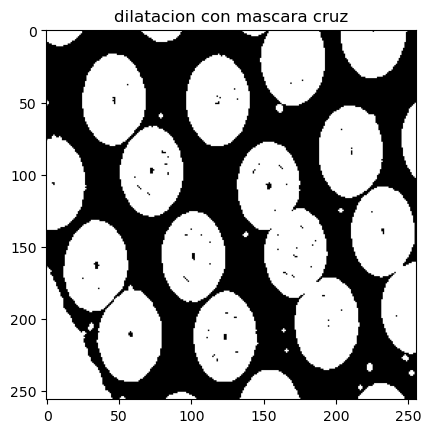

In [3]:
from skimage.morphology import dilation, erosion, opening, closing


mascara_cruz = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], np.uint8)

dilated_image = dilation(thresh_inv, footprint=mascara_cruz)

plt.imshow(dilated_image, cmap='gray')
plt.title('dilatacion con mascara cruz')
plt.show()


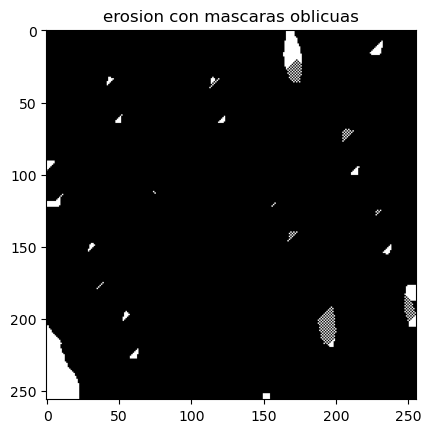

In [4]:

mascara_oblicua_descendente = np.array([[1, None, None], [None, 1, None], [None, None, 1]], dtype=object)
mascara_oblicua_ascendente = np.array([[None, None, 1], [None, 1, None], [1, None, None]], dtype=object)



eroded_image = erosion(dilated_image, footprint=mascara_oblicua_ascendente)

for i in range(9):
    eroded_image = erosion(eroded_image, footprint=mascara_oblicua_ascendente)

for i in range(6):
    eroded_image = erosion(eroded_image, footprint=mascara_oblicua_descendente)


plt.imshow(eroded_image, cmap='gray')
plt.title('erosion con mascaras oblicuas')
plt.show()




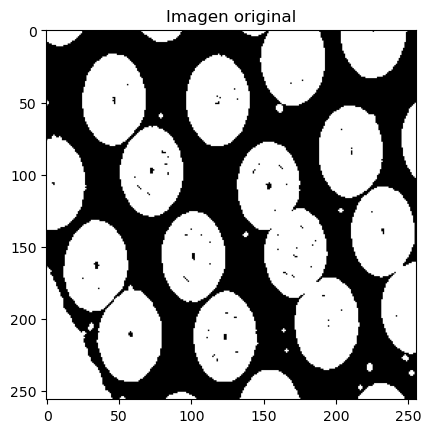

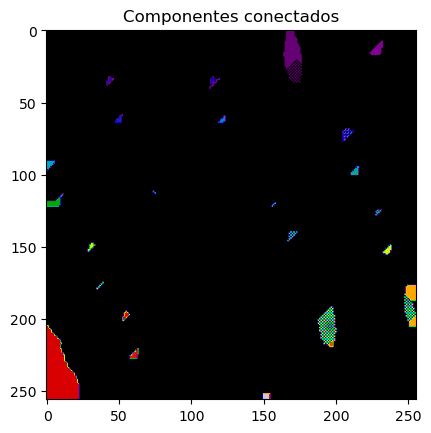

Total de células detectadas: 24


In [5]:
from skimage.measure import label


# Etiquetar componentes conexos con conectividad 8
connected_components  = label(eroded_image, background=0, connectivity=2)

plt.imshow(dilated_image, cmap='gray')
plt.title('Imagen original')
plt.show()

plt.imshow(connected_components, cmap='nipy_spectral')
plt.title('Componentes conectados')
plt.show()
num_cells = np.max(connected_components)
print(f"Total de células detectadas: {num_cells}")



# cantidad de células y borde

El método en los bordes puede llegar a perder información, lo que lleva a que no detecte una célula que realmente sí existe. Esto se debe a que como hay menos región, al momento de acotar el area puede llegar a desaparecer. 

En cuanto a la cantidad de células detectadas, inicialmente se podría tomar el número de diferentes colores que se utilizaron para representar los diferentes componentes conectados, por lo cual se podría decir que es de 24 células. Sin embargo, sabemos que en la esquina inferior derecha hay un área que también detecta por lo que encontró 23 células. 